In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
dataset = pd.read_csv("Placement.csv")

In [4]:
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [5]:
#To get the data summery

In [6]:
dataset.describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [7]:
dataset["ssc_p"].skew()


-0.13264949031456927

In [ ]:
#since skew is negative it has "Mean < Median < Mode"

In [8]:
dataset["ssc_p"].kurtosis()

-0.6075102066986688

In [ ]:
#Since value is <3 it is low / Platykurtic 

<Axes: >

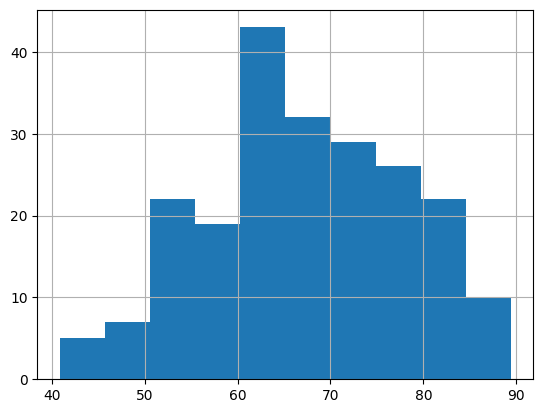

In [11]:
dataset["ssc_p"].hist()

In [14]:
quan=[]
qual=[]
for columnName in dataset.columns:
    #print(columnName)
    if(dataset[columnName].dtype=='O'):
        #print("qual")
        qual.append(columnName)
    else:
        #print("quan")
        quan.append(columnName)
        


In [15]:
def quanQual(dataset):
    quan=[]
    qual=[]
    for columnName in dataset.columns:
        #print(columnName)
        if(dataset[columnName].dtype=='O'):
            #print("qual")
            qual.append(columnName)
        else:
            #print("quan")
            quan.append(columnName)
    return quan,qual



In [22]:
for column in lesser:
    dataset[column][dataset[column]<descriptive[column]["Lesser"]]=descriptive[column]["Lesser"]
for column in greater:
    dataset[column][dataset[column]>descriptive[column]["Greater"]]=descriptive[column]["Greater"]


In [23]:
def Univariate(dataset,quan):
    descriptive=pd.DataFrame(index=["Mean","Median","Mode","Q1:25%","Q2:50%",
                               "Q3:75%","99%","Q4:100%","IQR","1.5rule","Lesser","Greater",
                                    "Min","Max","kurtosis","skew"],columns=quan)
    for columnName in quan:
        descriptive[columnName]["Mean"]=dataset[columnName].mean()
        descriptive[columnName]["Median"]=dataset[columnName].median()
        descriptive[columnName]["Mode"]=dataset[columnName].mode()[0]
        descriptive[columnName]["Q1:25%"]=dataset.describe()[columnName]["25%"]
        descriptive[columnName]["Q2:50%"]=dataset.describe()[columnName]["50%"]
        descriptive[columnName]["Q3:75%"]=dataset.describe()[columnName]["75%"]
        descriptive[columnName]["99%"]=np.percentile(dataset[columnName],99)
        descriptive[columnName]["Q4:100%"]=dataset.describe()[columnName]["max"]
        descriptive[columnName]["IQR"]=descriptive[columnName]["Q3:75%"]-descriptive[columnName]["Q1:25%"]
        descriptive[columnName]["1.5rule"]=1.5*descriptive[columnName]["IQR"]
        descriptive[columnName]["Lesser"]=descriptive[columnName]["Q1:25%"]-descriptive[columnName]["1.5rule"]
        descriptive[columnName]["Greater"]=descriptive[columnName]["Q3:75%"]+descriptive[columnName]["1.5rule"]
        descriptive[columnName]["Min"]=dataset[columnName].min()
        descriptive[columnName]["Max"]=dataset[columnName].max()
        descriptive[columnName]["kurtosis"]=dataset[columnName].kurtosis()
        descriptive[columnName]["skew"]=dataset[columnName].skew()
    return descriptive

In [24]:
Univariate(dataset,quan)

C:\Users\User\AppData\Local\Temp\ipykernel_13600\2165194013.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  descriptive[columnName]["Mean"]=dataset[columnName].mean()
C:\Users\User\AppData\Local\Temp\ipykernel_13600\2165194013.py:7: Futu

C:\Users\User\AppData\Local\Temp\ipykernel_13600\2165194013.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  descriptive[columnName]["Q2:50%"]=dataset.describe()[columnName]["50%"]
C:\Users\User\AppData\Local\Temp\ipykernel_13600\2165194

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
Mean,108.0,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
Median,108.0,67.0,65.0,66.0,71.0,62.0,265000.0
Mode,1,62.0,63.0,65.0,60.0,56.7,300000.0
Q1:25%,54.5,60.6,60.9,61.0,60.0,57.945,240000.0
Q2:50%,108.0,67.0,65.0,66.0,71.0,62.0,265000.0
Q3:75%,161.5,75.7,73.0,72.0,83.5,66.255,300000.0
99%,212.86,87.0,91.86,83.86,97.0,76.1142,NaN
Q4:100%,215.0,89.4,97.7,91.0,98.0,77.89,940000.0
IQR,107.0,15.1,12.1,11.0,23.5,8.31,60000.0
1.5rule,160.5,22.65,18.15,16.5,35.25,12.465,90000.0
